<a href="https://colab.research.google.com/github/JuanEnrique702/2094297_Examen-IAyRN/blob/main/Examen_IAyRN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Dataset con Pandas, NumPy y Matplotlib

En este notebook se realizará la carga, limpieza, análisis y visualización de un dataset utilizando Python y las librerías:
- Pandas
- NumPy
- Matplotlib

El objetivo es analizar datos, limpiar registros inválidos y generar visualizaciones para comprender mejor la información.

## Parte 1: Carga y Limpieza (Pandas y NumPy)

En esta sección se realizará:
- Importación de librerías
- Lectura del dataset desde una URL
- Exploración básica de los datos
- Limpieza de filas con dimensiones inválidas
- Creación de una nueva variable llamada volumen_aprox

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"

df = pd.read_csv(url)

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
print("Últimas 5 filas del dataset:")
print(df.tail())

print("\nResumen estadístico:")
print(df.describe())

Últimas 5 filas del dataset:
       carat        cut color clarity  depth  table  price     x     y     z
53935   0.72      Ideal     D     SI1   60.8   57.0   2757  5.75  5.76  3.50
53936   0.72       Good     D     SI1   63.1   55.0   2757  5.69  5.75  3.61
53937   0.70  Very Good     D     SI1   62.8   60.0   2757  5.66  5.68  3.56
53938   0.86    Premium     H     SI2   61.0   58.0   2757  6.15  6.12  3.74
53939   0.75      Ideal     D     SI2   62.2   55.0   2757  5.83  5.87  3.64

Resumen estadístico:
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.200000     43.000000     43.000000    326.000000      0.000000   
25%        0.400000     61.000000     56.000000    950.000000      4.710000   
50%        0.

In [4]:
df = df[(df['x'] != 0) & (df['y'] != 0) & (df['z'] != 0)]

In [5]:
df["volumen_aprox"] = df["x"] * df["y"] * df["z"]

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,volumen_aprox
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,38.202030
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,34.505856
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,38.076885
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,46.724580
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,51.917250


## Parte 2: Visualización de Datos (Matplotlib)

En esta sección se generarán tres gráficas:

- Gráfico de Caja (Boxplot) para analizar la distribución del precio.
- Gráfico de Dispersión (Scatter) para observar la relación entre volumen y precio.
- Gráfico de Barras para ver la cantidad de piezas por tipo de corte.

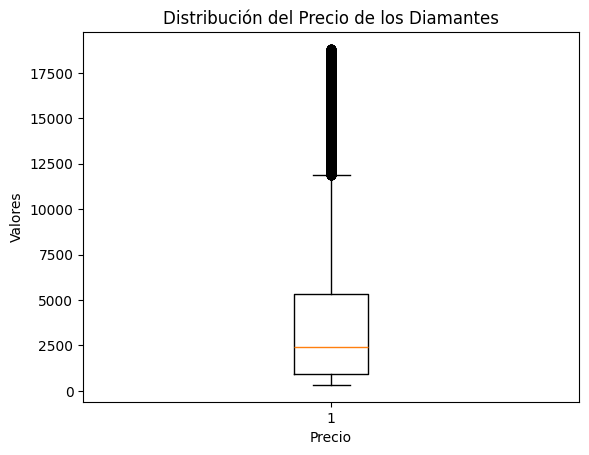

In [6]:
plt.figure()

plt.boxplot(df["price"])

plt.title("Distribución del Precio de los Diamantes")
plt.xlabel("Precio")
plt.ylabel("Valores")

plt.show()

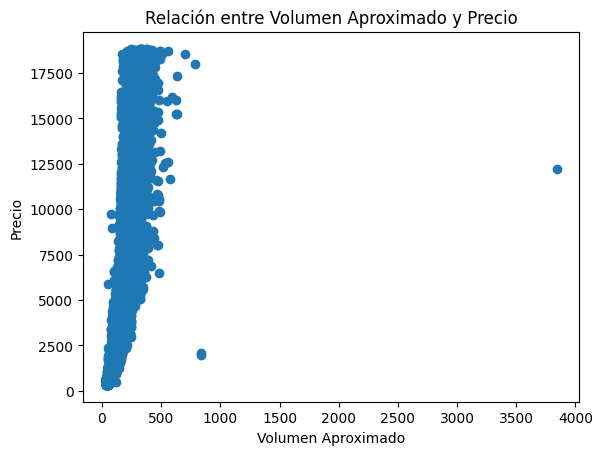

In [7]:
plt.figure()

plt.scatter(df["volumen_aprox"], df["price"])

plt.title("Relación entre Volumen Aproximado y Precio")
plt.xlabel("Volumen Aproximado")
plt.ylabel("Precio")

plt.show()

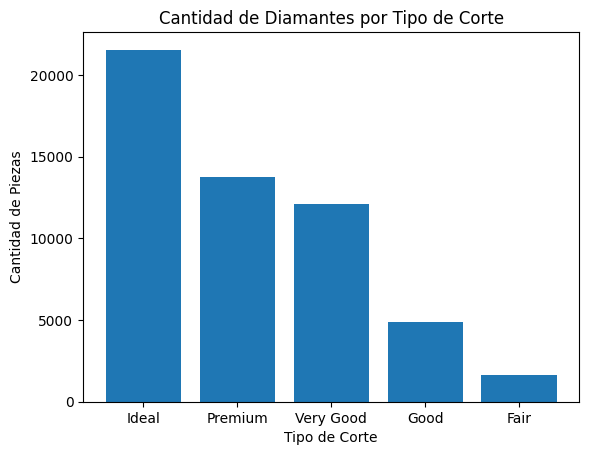

In [8]:
conteo_cortes = df["cut"].value_counts()

plt.figure()

plt.bar(conteo_cortes.index, conteo_cortes.values)

plt.title("Cantidad de Diamantes por Tipo de Corte")
plt.xlabel("Tipo de Corte")
plt.ylabel("Cantidad de Piezas")

plt.show()